# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama:SHAH FIRIZKI AZMI
- Email:2200018178@webmail.uad.ac.id
- Id Dicoding:shah-firizki-azmi

## Persiapan

### Menyiapkan library yang dibutuhkan

In [11]:
# ============================================================================
# SECTION 1: SETUP ENVIRONMENT - IMPORT ALL REQUIRED LIBRARIES
# ============================================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization & Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Model Training
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

# Model Persistence & Serialization
import joblib

# Utility
import warnings
warnings.filterwarnings('ignore')

print("All required libraries successfully imported!")
print("=" * 70)

All required libraries successfully imported!


### Menyiapkan data yang akan diguankan

## Data Understanding

In [12]:
# ============================================================================
# SECTION 2: LOAD DATA, EXPLORATION, DAN UNDERSTANDING
# VARIABEL YANG DIDEFINISIKAN: df, missing_count, status_counts, status_pct
# ============================================================================

print("\n📊 SECTION 2: MEMUAT DAN MEMAHAMI DATASET")
print("=" * 70)

import os
import urllib.request

# Coba berbagai path possibilities
possible_paths = [
    '../../Dataset/data.csv',
    '../Dataset/data.csv',
    'Dataset/data.csv',
    os.path.join('..', '..', 'Dataset', 'data.csv')
]

df = None  # ✅ DEFINE: df variable

# Coba load dari local path
for path in possible_paths:
    try:
        if os.path.exists(path):
            df = pd.read_csv(path, sep=';')
            print(f"✅ Dataset berhasil dimuat dari: {path}")
            break
    except Exception as e:
        continue

# Jika local path tidak ada, download dari GitHub
if df is None:
    print("📥 Mengunduh dataset dari GitHub...")
    try:
        url = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/students_performance/data.csv"
        df = pd.read_csv(url, sep=';')
        print(f"✅ Dataset berhasil diunduh dari GitHub!")
    except Exception as e:
        raise FileNotFoundError(f"Tidak dapat memuat dataset: {e}")

print(f"\n✅ Dataset berhasil dimuat!")
print(f"\n📌 DIMENSI DATASET:")
print(f"   • Total Baris (Records): {df.shape[0]:,}")
print(f"   • Total Kolom (Features): {df.shape[1]}")
print(f"   • Memory Usage: {df.memory_usage(deep=True).sum() / 1024 / 1024:.2f} MB")

print(f"\n📌 INFORMASI DATASET:")
print(f"   • First Column: {df.columns[0]}")
print(f"   • Last Column: {df.columns[-1]}")

print(f"\n📌 MISSING VALUES:")
missing_count = df.isnull().sum().sum()  # ✅ DEFINE: missing_count
print(f"   • Total Missing Values: {missing_count}")

print(f"\n📌 TARGET VARIABLE (Status) - DISTRIBUSI AWAL:")
status_counts = df['Status'].value_counts()  # ✅ DEFINE: status_counts
status_pct = df['Status'].value_counts(normalize=True) * 100  # ✅ DEFINE: status_pct
for status in status_counts.index:
    print(f"   • {status}: {status_counts[status]:,} records ({status_pct[status]:.1f}%)")

print(f"\n✅ Data Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\n✅ Dataset Understanding Complete!")


📊 SECTION 2: MEMUAT DAN MEMAHAMI DATASET
✅ Dataset berhasil dimuat dari: ../Dataset/data.csv

✅ Dataset berhasil dimuat!

📌 DIMENSI DATASET:
   • Total Baris (Records): 4,424
   • Total Kolom (Features): 31
   • Memory Usage: 5.29 MB

📌 INFORMASI DATASET:
   • First Column: Status
   • Last Column: Probability_Graduate

📌 MISSING VALUES:
   • Total Missing Values: 0

📌 TARGET VARIABLE (Status) - DISTRIBUSI AWAL:
   • Graduate: 2,209 records (49.9%)
   • Dropout: 1,421 records (32.1%)
   • Enrolled: 794 records (17.9%)

✅ Data Shape: 4424 rows × 31 columns

✅ Dataset Understanding Complete!


## Data Preparation / Preprocessing

📊 EDA UNIVARIATE: VARIABEL NUMERIK

Variabel Numerik (21): ['Prediction_Confidence', 'Prediction_Correct', 'Gender', 'Age_at_enrollment', 'Marital_status', 'International', 'Displaced', 'Course', 'Admission_grade', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Educational_special_needs', 'Scholarship_holder', 'Tuition_fees_up_to_date', 'Debtor', 'Daytime_evening_attendance', 'Probability_Dropout', 'Probability_Enrolled', 'Probability_Graduate']


Prediction_Confidence:
  Mean: 77.17
  Median: 83.36
  Std Dev: 18.29
  Min: 33.59
  Max: 99.93
  Skewness: -0.61
  Kurtosis: -0.96

Prediction_Correct:
  Mean: 0.77
  Median: 1.00
  Std Dev: 0.42
  Min: 0.00
  Max: 1.00
  Skewness: -1.30
  Kurtosis: -0.32

Gender:
  Mean: 0.35
  Median: 0.00
  Std Dev: 0.48
  Min: 0.00
  Max: 1.00
  Skewness: 0.62
  Kurtosis: -1.61

Age_at_enrollment:
  Mean: 23.27
  Median: 20.00
  Std Dev: 7.59
  Min: 17.00
  Ma

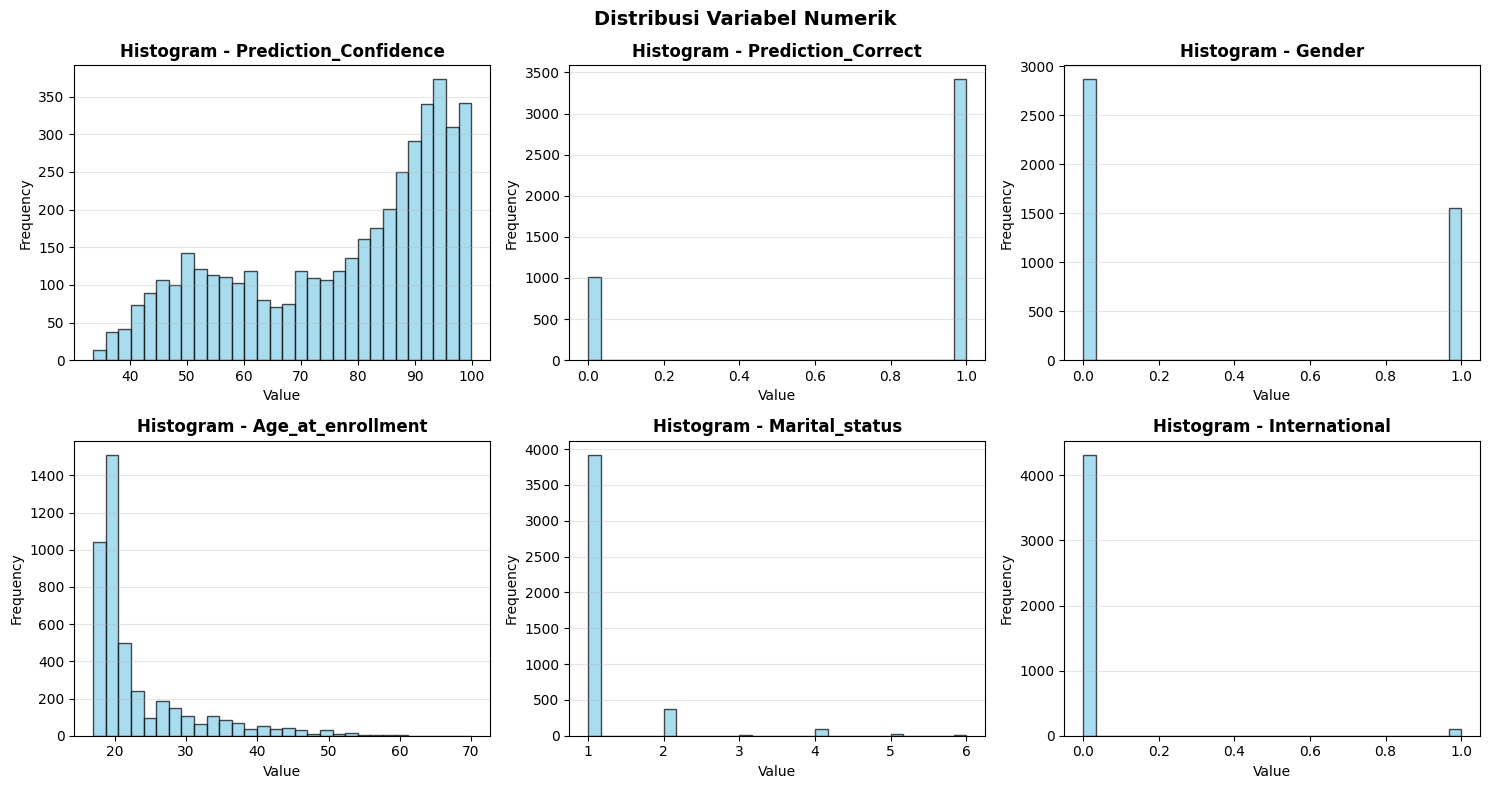


📊 EDA UNIVARIATE: VARIABEL KATEGORIKAL

Variabel Kategorikal (10): ['Status', 'Model_Prediction', 'Gender_Label', 'International_Label', 'Displaced_Label', 'Special_Needs_Label', 'Scholarship_Label', 'Tuition_Label', 'Debtor_Label', 'Attendance_Label']


Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64
Unique values: 3

Model_Prediction:
Model_Prediction
Graduate    2598
Dropout     1335
Enrolled     491
Name: count, dtype: int64
Unique values: 3

Gender_Label:
Gender_Label
👩 Perempuan (Female)    2868
👨 Laki-laki (Male)      1556
Name: count, dtype: int64
Unique values: 2

International_Label:
International_Label
🇵🇹 Domestik        4314
🌍 Internasional     110
Name: count, dtype: int64
Unique values: 2

Displaced_Label:
Displaced_Label
📍 Pindah          2426
🏠 Tidak Pindah    1998
Name: count, dtype: int64
Unique values: 2

🎯 ANALISIS TARGET VARIABLE: Status

Distribusi Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: 

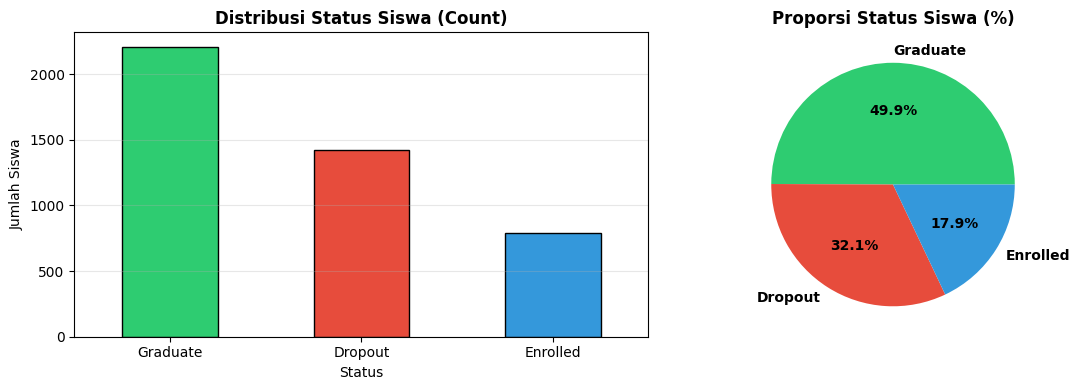


✅ EDA UNIVARIATE - SELESAI!


In [13]:
# ============================================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA) UNIVARIATE
# VARIABEL PREREQUISITE: df (dari Section 2)
# VARIABEL YANG DIDEFINISIKAN: numeric_cols, categorical_cols, fig, axes
# ============================================================================

# Analisis Univariate - Variabel Numerik
print("="*60)
print("📊 EDA UNIVARIATE: VARIABEL NUMERIK")
print("="*60)

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns  # ✅ DEFINE: numeric_cols
print(f"\nVariabel Numerik ({len(numeric_cols)}): {list(numeric_cols)}\n")

# Statistik deskriptif untuk setiap variabel numerik
for col in numeric_cols[:5]:  # Tampilkan 5 kolom pertama
    print(f"\n{col}:")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std Dev: {df[col].std():.2f}")
    print(f"  Min: {df[col].min():.2f}")
    print(f"  Max: {df[col].max():.2f}")
    print(f"  Skewness: {df[col].skew():.2f}")
    print(f"  Kurtosis: {df[col].kurtosis():.2f}")

# Visualisasi distribusi variabel numerik
fig, axes = plt.subplots(2, 3, figsize=(15, 8))  # ✅ DEFINE: fig, axes
fig.suptitle('Distribusi Variabel Numerik', fontsize=14, fontweight='bold')

numeric_sample = [col for col in numeric_cols if col != 'Status'][:6]
for idx, col in enumerate(numeric_sample):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Histogram - {col}', fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Analisis Univariate - Variabel Kategorikal
print("\n" + "="*60)
print("📊 EDA UNIVARIATE: VARIABEL KATEGORIKAL")
print("="*60)

categorical_cols = df.select_dtypes(include=['object']).columns  # ✅ DEFINE: categorical_cols
print(f"\nVariabel Kategorikal ({len(categorical_cols)}): {list(categorical_cols)}\n")

for col in categorical_cols[:5]:  # Tampilkan 5 kolom pertama
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"Unique values: {df[col].nunique()}")


# Analisis TARGET VARIABLE - Status
print("\n" + "="*60)
print("🎯 ANALISIS TARGET VARIABLE: Status")
print("="*60)
print("\nDistribusi Status:")
print(df['Status'].value_counts())
print("\nProporsi Status (%):")
print(df['Status'].value_counts(normalize=True) * 100)

# Visualisasi Status
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # ✅ REDEFINE: fig, axes
df['Status'].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c', '#3498db'], edgecolor='black')
axes[0].set_title('Distribusi Status Siswa (Count)', fontweight='bold')
axes[0].set_ylabel('Jumlah Siswa')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

df['Status'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   colors=['#2ecc71', '#e74c3c', '#3498db'],
                                   textprops={'fontsize': 10, 'weight': 'bold'})
axes[1].set_title('Proporsi Status Siswa (%)', fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("\n✅ EDA UNIVARIATE - SELESAI!")

## Modeling

In [14]:
# ============================================================================
# SECTION 3.5: DATA FILTERING - HANYA DROPOUT & GRADUATE UNTUK TRAINING
# VARIABEL PREREQUISITE: df (dari Section 2)
# VARIABEL YANG DIDEFINISIKAN: df_training, status_before, status_after,
#                               dropout_count, graduate_count
# ============================================================================

print("\n" + "="*70)
print("PENTING: FILTERING DATA UNTUK MODEL TRAINING")
print("="*70)

print("""\n⚠️ CATATAN PENTING - Status "Enrolled" dalam Model Training:
   
Tujuan Model: Memprediksi apakah siswa akan DROPOUT atau GRADUATE
   
Alasan Filtering:
   • Status "Dropout": Siswa sudah tidak melanjutkan studi (LABEL AKHIR)
   • Status "Graduate": Siswa sudah menyelesaikan studi (LABEL AKHIR)
   • Status "Enrolled": Siswa MASIH AKTIF belajar (TIDAK ADA LABEL AKHIR)
   
Mengapa Enrolled tidak digunakan untuk training:
   ✗ Enrolled belum memiliki hasil akhir yang definitif
   ✗ Menggunakannya akan membuat target label menjadi tidak jelas
   ✗ Validation akan menjadi tidak valid karena mencampur dengan outcome akhir
   ✓ Enrolled hanya boleh digunakan di tahap INFERENSI/PREDIKSI untuk
     memprediksi kemungkinan status akhir siswa di masa depan
""")

print("\n📊 STATUS DISTRIBUTION SEBELUM FILTERING:")
status_before = df['Status'].value_counts()  # ✅ DEFINE: status_before
print(status_before)
print(f"\nTotal records sebelum filter: {len(df):,}")

# Filter data untuk hanya Dropout dan Graduate
df_training = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()  # ✅ DEFINE: df_training

print("\n📊 STATUS DISTRIBUTION SESUDAH FILTERING (HANYA DROPOUT & GRADUATE):")
status_after = df_training['Status'].value_counts()  # ✅ DEFINE: status_after
print(status_after)
print(f"\nTotal records sesudah filter: {len(df_training):,}")

dropout_count = (df_training['Status'] == 'Dropout').sum()  # ✅ DEFINE: dropout_count
graduate_count = (df_training['Status'] == 'Graduate').sum()  # ✅ DEFINE: graduate_count

print(f"\n✅ SUMMARY DATA FILTERING:")
print(f"   • Dropout: {dropout_count:,} ({dropout_count/len(df_training)*100:.1f}%)")
print(f"   • Graduate: {graduate_count:,} ({graduate_count/len(df_training)*100:.1f}%)")
print(f"   • Enrolled: DIKECUALIKAN dari training (akan digunakan untuk prediksi)")
print(f"   • Total training data: {len(df_training):,} records")
print(f"   • Records yang dikecualikan: {len(df) - len(df_training):,}")

print("\n✅ Data sudah siap untuk training dengan label yang JELAS dan VALID!")


PENTING: FILTERING DATA UNTUK MODEL TRAINING

⚠️ CATATAN PENTING - Status "Enrolled" dalam Model Training:

Tujuan Model: Memprediksi apakah siswa akan DROPOUT atau GRADUATE

Alasan Filtering:
   • Status "Dropout": Siswa sudah tidak melanjutkan studi (LABEL AKHIR)
   • Status "Graduate": Siswa sudah menyelesaikan studi (LABEL AKHIR)
   • Status "Enrolled": Siswa MASIH AKTIF belajar (TIDAK ADA LABEL AKHIR)

Mengapa Enrolled tidak digunakan untuk training:
   ✗ Enrolled belum memiliki hasil akhir yang definitif
   ✗ Menggunakannya akan membuat target label menjadi tidak jelas
   ✗ Validation akan menjadi tidak valid karena mencampur dengan outcome akhir
   ✓ Enrolled hanya boleh digunakan di tahap INFERENSI/PREDIKSI untuk
     memprediksi kemungkinan status akhir siswa di masa depan


📊 STATUS DISTRIBUTION SEBELUM FILTERING:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Total records sebelum filter: 4,424

📊 STATUS DISTRIBUTION SESUDAH FILTERING (

## Evaluation

In [15]:
# ============================================================================
# SECTION 4: DATA PREPARATION & PREPROCESSING (USING FILTERED DATA)
# VARIABEL PREREQUISITE: df_training (dari Section 3.5 - HANYA DROPOUT & GRADUATE)
# VARIABEL YANG DIDEFINISIKAN: X, y, categorical_features, label_encoders,
#                               le_target, y_encoded, X_filled, X_train, X_test,
#                               y_train, y_test, scaler, X_train_scaled, X_test_scaled
# ============================================================================

print("\n🔧 SECTION 4: DATA PREPROCESSING (FILTERED FOR TRAINING)")
print("=" * 70)

# Step 1: Separasi features dan target dari df_training (yang sudah difilter)
X = df_training.drop('Status', axis=1)  # ✅ DEFINE: X
y = df_training['Status']  # ✅ DEFINE: y

print(f"\n✅ Features (X) dan Target (y) telah dipisahkan (dari FILTERED DATA)")
print(f"   • X Shape: {X.shape}")
print(f"   • y Shape: {y.shape}")
print(f"   • Perhatian: Data hanya mencakup Dropout dan Graduate")

# Step 2: Identifikasi dan encode categorical variables
categorical_features = X.select_dtypes(include=['object']).columns.tolist()  # ✅ DEFINE: categorical_features
label_encoders = {}  # ✅ DEFINE: label_encoders

print(f"\n✅ Encoding categorical variables...")
for col in categorical_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"   • {col}: {len(le.classes_)} unique values encoded")

# Step 3: Encode target variable (HANYA Dropout dan Graduate)
le_target = LabelEncoder()  # ✅ DEFINE: le_target
y_encoded = le_target.fit_transform(y)  # ✅ DEFINE: y_encoded

print(f"\n✅ Target Variable (Status) encoded (HANYA 2 CLASSES):")
for idx, label in enumerate(le_target.classes_):
    print(f"   • {label} → {idx}")

# Step 4: Handle missing values
print(f"\n✅ Handling missing values...")
X_filled = X.fillna(X.mean(numeric_only=True))  # ✅ DEFINE: X_filled
print(f"   • Missing values handled (filled dengan mean untuk numeric columns)")

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(  # ✅ DEFINE: X_train, X_test, y_train, y_test
    X_filled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\n✅ Data split menjadi train dan test:")
print(f"   • Training set: {X_train.shape[0]:,} records ({(X_train.shape[0]/len(X_filled)*100):.1f}%)")
print(f"   • Test set: {X_test.shape[0]:,} records ({(X_test.shape[0]/len(X_filled)*100):.1f}%)")
print(f"   • Train target distribution: {np.bincount(y_train)}")
print(f"   • Test target distribution: {np.bincount(y_test)}")

# Step 6: Feature scaling
scaler = StandardScaler()  # ✅ DEFINE: scaler
X_train_scaled = scaler.fit_transform(X_train)  # ✅ DEFINE: X_train_scaled
X_test_scaled = scaler.transform(X_test)  # ✅ DEFINE: X_test_scaled

print(f"\n✅ Features di-scaling dengan StandardScaler:")
print(f"   • Mean (should be ~0): {X_train_scaled.mean(axis=0)[:3]}")
print(f"   • Std (should be ~1): {X_train_scaled.std(axis=0)[:3]}")

print("\n✅ Data Preprocessing Complete - Siap untuk Model Training (VALID & CORRECT LABELED DATA)")


🔧 SECTION 4: DATA PREPROCESSING (FILTERED FOR TRAINING)

✅ Features (X) dan Target (y) telah dipisahkan (dari FILTERED DATA)
   • X Shape: (3630, 30)
   • y Shape: (3630,)
   • Perhatian: Data hanya mencakup Dropout dan Graduate

✅ Encoding categorical variables...
   • Model_Prediction: 3 unique values encoded
   • Gender_Label: 2 unique values encoded
   • International_Label: 2 unique values encoded
   • Displaced_Label: 2 unique values encoded
   • Special_Needs_Label: 2 unique values encoded
   • Scholarship_Label: 2 unique values encoded
   • Tuition_Label: 2 unique values encoded
   • Debtor_Label: 2 unique values encoded
   • Attendance_Label: 2 unique values encoded

✅ Target Variable (Status) encoded (HANYA 2 CLASSES):
   • Dropout → 0
   • Graduate → 1

✅ Handling missing values...
   • Missing values handled (filled dengan mean untuk numeric columns)

✅ Data split menjadi train dan test:
   • Training set: 2,904 records (80.0%)
   • Test set: 726 records (20.0%)
   • Train